Datele sunt accesate din: Capstone_Architectural_Styles_dataset_preprocessed


c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\fastai\torch_core.py:263: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return getattr(torch, 'has_mps', False)


DataLoaders creați cu succes.
   Numărul de clase (stiluri): 46
   Număr imagini pentru antrenament: 10356
   Număr imagini pentru validare: 2588


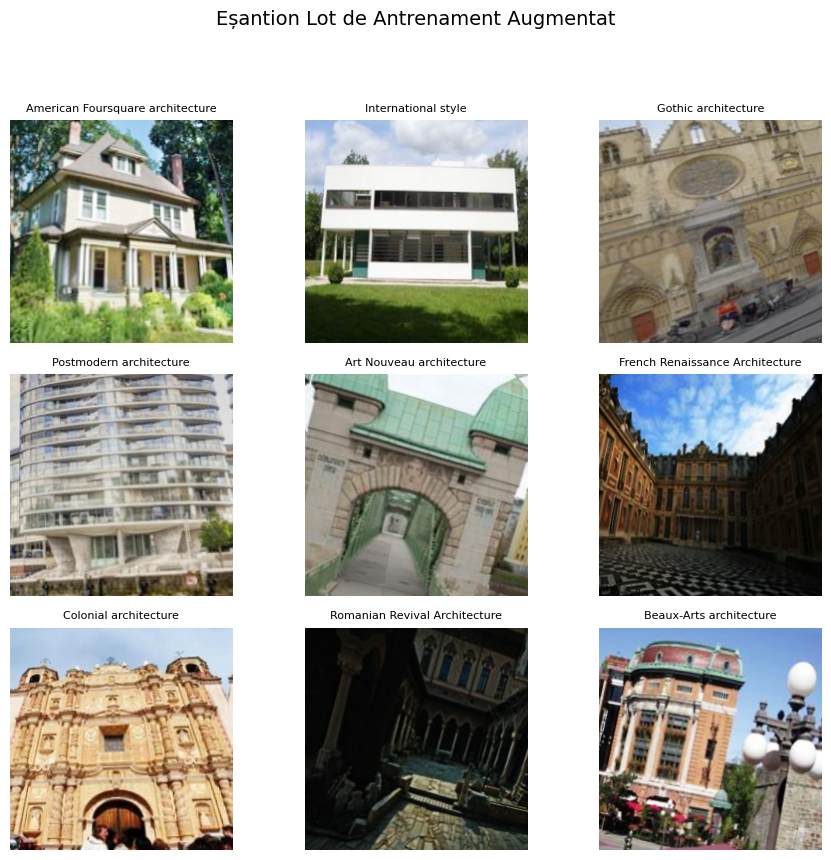

In [1]:
import os
from pathlib import Path
import random
import numpy as np

from fastai.vision.all import *
from functools import partial
from fastai.callback.tracker import EarlyStoppingCallback, SaveModelCallback

#Pentru a asigura rezultate reproductibile
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

#De schimbat căile cu ce e nevoie
DATA_DIR = Path("Capstone_Architectural_Styles_dataset_preprocessed")
MODEL_EXPORT_PATH = Path("architectural_style_model_fastai_resnet34_2.pkl")

IMG_SIZE = 224
BATCH_SIZE = 32
VALID_PCT = 0.2 # 20% din date vor fi folosite pentru validare, și 80% pentru antrenare

BASE_LEARNING_RATE = 1e-3 # Rata de învățare de bază for fine_tune sau 1e-3 sau 5e-4 sau 3e-4

# --- 0. Verificarea directorului de date ---
if not DATA_DIR.is_dir():
    print(f"EROARE: Directorul de date '{DATA_DIR}' nu există sau nu este un director.")
    exit()

print(f"Datele sunt accesate din: {DATA_DIR}")

# --- 1. Încărcarea și augmentarea datelor---
# Se aplică mai întâi transformări pe imagini individuale (pe CPU) iar apoi pe lot (pe GPU)
item_tfms = RandomResizedCrop(IMG_SIZE, min_scale=0.75)#pentru decuparea a 25% din poză
batch_tfms = [*aug_transforms(mult=1.0, # Multiplicator pentru intensitatea transformărilor de augmentare default
                                do_flip=True,      # Aplică răsturnare orizontală
                                flip_vert=False,   # Nu aplica răsturnare verticală
                                max_rotate=20.0,   # Rotație maximă în grade
                                min_zoom=1.0,
                                max_zoom=1.2,
                                max_lighting=0.3, # Modificare maximă a luminozității
                                max_warp=0.15,      # Deformare maximă a perspectivei
                                p_affine=0.8,     # Probabilitatea aplicării transformărilor afine (rotație, zoom)
                                p_lighting=0.8,   # Probabilitatea aplicării transformărilor de luminozitate
                                # pad_mode poate fi 'zeros', 'border' sau 'reflection'
                                pad_mode='reflection'
                                ),
              Normalize.from_stats(*imagenet_stats) # Normalizează folosind statisticile ImageNet
             ]

try:
    # ImageDataLoaders.from_folder deduce automat clasele din numele directoarelor.
    dls = ImageDataLoaders.from_folder(
        DATA_DIR,
        valid_pct=VALID_PCT,
        item_tfms=item_tfms,
        batch_tfms=batch_tfms,
        bs=BATCH_SIZE,
        seed=42, # Pentru o împărțire reproductibilă
        num_workers=0 if os.name == 'nt' else min(8, os.cpu_count()) # num_workers poate cauza probleme pe Windows
    )
except Exception as e:
    print(f"Eroare la crearea ImageDataLoaders: {e}")
    exit()

if len(dls.train_ds) == 0 or len(dls.valid_ds) == 0:
    print(f"Nicio imagine de antrenament sau validare nu a fost găsită de ImageDataLoaders. Vă rugăm verificați:")
    print(f"1. Structura directorului DATA_DIR ('{DATA_DIR}'). Ar trebui să conțină subdirectoare pentru fiecare stil.")
    print(f"2. Că aceste subdirectoare conțin fișiere imagine valide (jpg, png, etc.).")
    exit()

print(f"DataLoaders creați cu succes.")
print(f"   Numărul de clase (stiluri): {dls.c}")
print(f"   Număr imagini pentru antrenament: {len(dls.train_ds)}")
print(f"   Număr imagini pentru validare: {len(dls.valid_ds)}")

dls.show_batch(max_n=9, figsize=(9,9))
plt.suptitle("Eșantion Lot de Antrenament Augmentat", fontsize=14)
fig = plt.gcf() 
for ax in fig.get_axes():
    if ax.get_title(): 
        ax.title.set_fontsize(8)
plt.tight_layout(rect=[0, 0.03, 1, 0.93]) 
plt.show()

Au fost găsite 47 stiluri. Se generează graficul distribuției...


C:\Users\user\AppData\Local\Temp\ipykernel_17052\2461404599.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


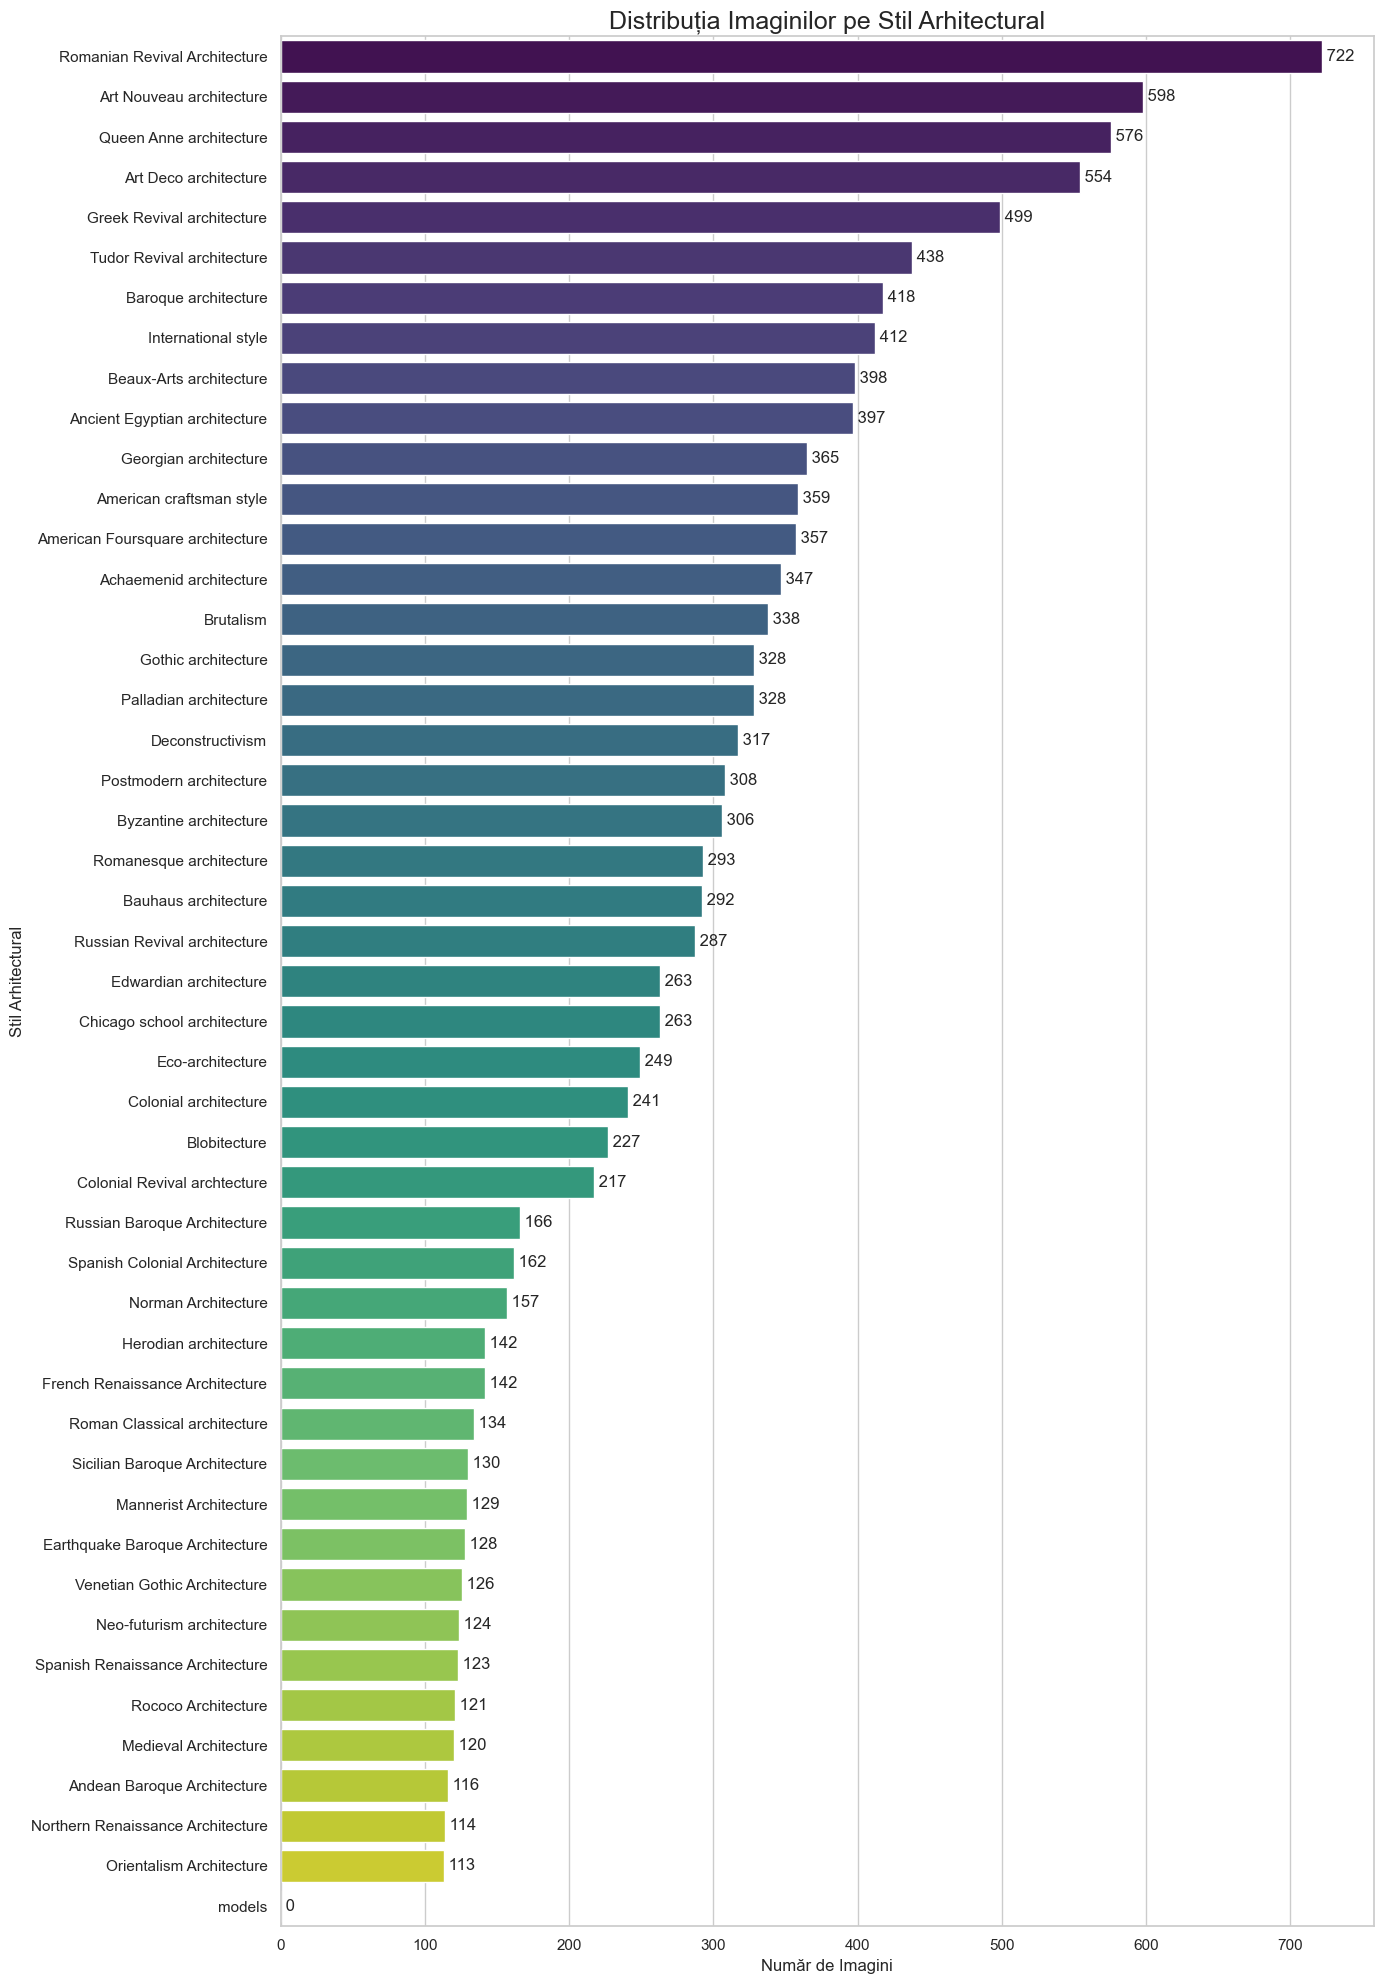

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Analiza Distribuției Claselor ---

DATA_PATH = Path("Capstone_Architectural_Styles_dataset_preprocessed") 

# Verifică dacă directorul există
if not DATA_PATH.is_dir():
    print(f"EROARE: Directorul '{DATA_PATH}' nu a fost găsit. Verifică calea.")
else:
    # 1. Colectează numărul de imagini pentru fiecare stil (clasă)
    style_counts = {}
    for style_dir in DATA_PATH.iterdir():
        if style_dir.is_dir():
            # Numără toate fișierele din subdirectorul stilului
            num_images = len(list(style_dir.glob('*.*'))) 
            style_counts[style_dir.name] = num_images

    # 2. Creează un DataFrame Pandas pentru a manipula datele mai ușor
    df_counts = pd.DataFrame(list(style_counts.items()), columns=['Stil', 'Numar_Imagini'])
    
    # Sortează stilurile după numărul de imagini pentru o vizualizare mai clară
    df_counts = df_counts.sort_values('Numar_Imagini', ascending=False)

    # 3. Generează graficul folosind Seaborn
    print(f"Au fost găsite {len(df_counts)} stiluri. Se generează graficul distribuției...")

    # Setează tema și dimensiunea graficului
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 20)) 

    # Creează graficul de tip bară orizontal
    barplot = sns.barplot(
        x='Numar_Imagini', 
        y='Stil', 
        data=df_counts, 
        palette='viridis' 
    )
    
    # Adaugă etichete numerice pe fiecare bară pentru claritate
    for index, value in enumerate(df_counts['Numar_Imagini']):
        plt.text(value, index, f' {value}', va='center')

    plt.title('Distribuția Imaginilor pe Stil Arhitectural', fontsize=18)
    plt.xlabel('Număr de Imagini', fontsize=12)
    plt.ylabel('Stil Arhitectural', fontsize=12)

    plt.tight_layout()
    plt.show()

In [ ]:
# --- 2. Antrenarea modelului (învățare prin transfer) ---
# Arhitectura pre-antrenată care va fi folosită
ARCH = resnet34  #Putem folosi diferite arhitecturi pentru modele diferite

# Definiție callbacks (funcții apelate în timpul antrenamentului)
callbacks_list = [
    # Salvează modelul de fiecare dată când acuratețea pe setul de validare se îmbunătățește
    SaveModelCallback(monitor='accuracy', comp=np.greater, fname=MODEL_EXPORT_PATH.stem + '_best_during_train', reset_on_fit=True),
    # Oprește antrenamentul dacă valid_loss (pierderea pe validare) nu se îmbunătățește cu min_delta timp de 'patience' epoci
    EarlyStoppingCallback(monitor='valid_loss', comp=np.less, min_delta=0.001, patience=5, reset_on_fit=True)
]

learn = vision_learner(
    dls,
    ARCH,
    metrics=[accuracy, error_rate, partial(top_k_accuracy, k=3)], 
    # cbs=[SaveModelCallback(monitor='accuracy', comp=np.greater)]
    wd = 0.05
)

#În cazul în care datele sunt de feedbacke se comentează mai sus și se decomentează mai jos
# learn = load_learner(MODEL_EXPORT_PATH)
# learn.dls = dls
# learn.unfreeze()

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to C:\Users\user/.cache\torch\hub\checkpoints\resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:51<00:00, 1.69MB/s]


In [4]:
#Găsire unei rate de învățare bune
lr_find_res = learn.lr_find() # obiect cu rate de învățare găsite
suggested_lr = lr_find_res.valley if lr_find_res.valley else lr_find_res.steep if lr_find_res.steep else BASE_LEARNING_RATE
print(f"Suggested learning rate from lr_find: {suggested_lr}")
if suggested_lr < 1e-6 : # în cazul în care rata găsită e prea mică
    print(f"Suggested LR {suggested_lr} is very small, using default BASE_LEARNING_RATE {BASE_LEARNING_RATE}")
    final_lr_to_use = BASE_LEARNING_RATE
else:
    final_lr_to_use = suggested_lr/2

print(final_lr_to_use) 

KeyboardInterrupt: 

In [ ]:
# Metoda `fine_tune` este o modalitate convenabilă de a realiza învățarea prin transfer (transfer learning):
# 1. Antrenează capul (head) adăugat aleatoriu pentru 1 epocă, cu modelul de bază înghețat (frozen).
# 2. Dezgheață toate straturile (sau un număr specificat de grupuri de straturi).
# 3. Antrenează întreaga rețea pentru numărul specificat de epoci, folosind rate de învățare diferențiate (discriminative learning rates).
NUM_FINE_TUNE_EPOCHS = 20 # Definește numărul de epoci pentru faza de antrenare a întregii rețele


learn.fine_tune(
    NUM_FINE_TUNE_EPOCHS,
    base_lr=BASE_LEARNING_RATE, # Rata de învățare de bază (probabil găsită cu lr_find)
    freeze_epochs=2, # Câte epoci să antreneze capul (implicit este 1 în fine_tune)
    cbs=callbacks_list # Lista de callbacks definită anterior
)

#În cazul în care datele de antrenare vin din feedback se comentează ce e mai sus și se decomentează asta:
#learn.fit_one_cycle(NUM_FINE_TUNE_EPOCHS, lr_max=final_lr_to_use)


c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\fastai\torch_core.py:263: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return getattr(torch, 'has_mps', False)


epoch,train_loss,valid_loss,accuracy,error_rate,top_k_accuracy,time


KeyboardInterrupt: 

In [11]:
torch.cuda.is_available()

False

In [ ]:
# --- 3. Afișarea și interpretarea rezultatelor ---

# --- Numărul de iterații (batch-uri) ---
# Numărul de epoci efectiv rulate (dacă antrenamentul s-a oprit devreme)
num_epoci_rulate = len(learn.recorder.values) # Sau learn.epoch [-1] + 1 dacă epoch începe de la 0

iteratii_antrenament_per_epoca = len(dls.train)
iteratii_validare_per_epoca = len(dls.valid)

total_iteratii_antrenament_efectuate = learn.recorder.n_iter 
# n_iter numără batch-urile de antrenament procesate de la ultimul reset al recorder-ului (de ex., la începutul fine_tune)

# Calculăm totalul iterațiilor de validare pe baza epocilor rulate pentru care avem valori de validare
total_iteratii_validare_efectuate = num_epoci_rulate * iteratii_validare_per_epoca

print("\n--- Statistici Iterații ---")
print(f"Numărul de epoci rulate efectiv: {num_epoci_rulate}")
print(f"Iterații de antrenament per epocă: {iteratii_antrenament_per_epoca}")
print(f"Iterații de validare per epocă: {iteratii_validare_per_epoca}")
print(f"Total iterații de antrenament efectuate (de la ultimul fit/fine_tune): {total_iteratii_antrenament_efectuate}")
print(f"Total iterații de validare efectuate (estimat): {total_iteratii_validare_efectuate}")
print("----------------------------\n")

# --- Grafice pentru Pierdere și Metrici de-a lungul iterațiilor/epocilor ---

# 1. Pierderea (Loss) de-a lungul iterațiilor/epocilor
print("Se generează graficul pentru pierdere (loss)...")
learn.recorder.plot_loss()
plt.suptitle("Pierderea de Antrenament (per lot) și Pierderea de Validare (per epocă)")
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

# 2. Metricile (de ex., acuratețea) de-a lungul epocilor
# Aceasta va afișa toate metricile pe care le-ai specificat la crearea Learner-ului
if hasattr(learn.recorder, 'plot_metrics') and learn.metrics:
    learn.recorder.plot_metrics()
    plt.suptitle("Metricile de Validare de-a lungul Epocilor")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
elif hasattr(learn.recorder, 'plot_accuracy') and any(m.name == 'accuracy' for m in learn.metrics): 
    learn.recorder.plot_accuracy()
    plt.suptitle("Acuratețea de Validare de-a lungul Epocilor")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("\nNu s-au găsit metrici standard (accuracy) sau metoda plot_metrics pentru a afișa graficul metricilor.")


# 3. Graficul pentru rata de învățare 
# Acest grafic arată cum a variat rata de învățare (și momentum-ul) pe parcursul antrenamentului.
# Este diferit de graficul lr_find(), care arată pierderea vs. rata de învățare *înainte* de antrenament.
if hasattr(learn.recorder, 'plot_sched'):
    print("\nSe generează graficul pentru programul ratei de învățare și momentum...")
    learn.recorder.plot_sched() 
    plt.suptitle("Programul Ratei de Învățare și al Momentum-ului Folosit în Timpul Antrenamentului")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("\nMetoda plot_sched() nu este disponibilă pentru a afișa programul ratei de învățare.")

print("\n--- Rezultate Specifice Modelului ---")
learn.show_results(max_n=9, figsize=(10,10))
plt.suptitle("Rezultate mostră de la validare (Imagine, stil prezis, stil real)")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

interp = ClassificationInterpretation.from_learner(learn)

interp.plot_confusion_matrix(figsize=(12,12), dpi=60)
plt.title("Matricea de confuzie")
plt.tight_layout()
plt.show()

interp.plot_top_losses(9, figsize=(15,11))
plt.suptitle("Top Losses (imaginile pentru care modelul a fost cel mai confuz)", fontsize=14)
fig = plt.gcf() 
for ax in fig.get_axes():
    if ax.get_title(): 
        ax.title.set_fontsize(8)
plt.tight_layout(rect=[0, 0.03, 1, 0.93]) 
plt.show()

In [ ]:
# --- 4. Salvarea modelului prin export pentru încărcare ulterioară---
learn.export(MODEL_EXPORT_PATH)
print(f"Modelul a fost exportat aici: {MODEL_EXPORT_PATH}")
print(f"Acest fișier '.pkl' conține arhitectura modelului, greutățile, și pipeline-ul de transformare a datelor.")